https://prappleizer.github.io/Tutorials/MCMC/MCMC_Tutorial_Solution.html

http://dfm.io/george/current/user/model/

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import emcee
import getdist
import pandas as pd
import afterglowpy as grb

from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from dustmaps.sfd import SFDQuery
from getdist import plots, MCSamples

In [4]:
from orphans.tools import pseudo_obs_with_points, GalacticExtinction

path_dustmaps = '../data/schlafly_dust_factor.csv'

In [5]:
# take one light curve with enough points among all the pseudo-observations

file_open = open(f'../data/pseudo_obs/pseudo_obs_PL_015_1000.pkl', 'rb')
pseudo_obs = pickle.load(file_open)
file_open.close()

lc_with_pts = pseudo_obs_with_points(pseudo_obs)

df = pd.DataFrame(lc_with_pts)
studied_lc = df.iloc[9]

In [6]:
# compute galactic extinction to remove it in the data

coord = studied_lc['grb_coord']
a_lambda_u, a_lambda_g, a_lambda_r, a_lambda_i, a_lambda_z, a_lambda_y = GalacticExtinction(coord, path_dustmaps)

In [7]:
# keeping only observable points and sorting them by filters

mags = studied_lc['mags']
filt = studied_lc['filt']
mags_lim = studied_lc['mags_lim']
mags_err = studied_lc['mags_err']
time = studied_lc['time']

colors = ['b', 'c', 'g', 'orange', 'r', 'm']
all_mags = [[]]*6
all_mags_err = [[]]*6
all_times = [[]]*6


for c in colors:
    
    all_mags[colors.index(c)] = np.array([mags[i] for i in range(len(mags)) if filt[i] == c and
                                      mags[i] < mags_lim[i]])
    
    all_mags_err[colors.index(c)] = np.array([mags_err[i] for i in range(len(mags_err))
                                          if filt[i] == c and mags[i] < mags_lim[i]])
    
    all_times[colors.index(c)] = np.array([(time[i]-Time(df.iloc[9]['grb_time']).mjd)
                                       for i in range(len(time)) if filt[i] == c and mags[i] < mags_lim[i]])
                                       # time counted from from GRB T_0 ('grb_time')

# Fitting on the r-band

In [8]:
# data calculated in flux and corrected from galactic extinction

t = all_times[2]
y = pow(10, (26 - ((np.array(all_mags[2]) - a_lambda_r) + 48.6) / 2.5))
yerr = pow(10, (26 - ((np.array(all_mags[2]) - a_lambda_r) + all_mags_err[2] + 48.6) / 2.5)) - y

In [9]:
def model(t, nu, params):
    
    Z = {'jetType': -1,
         'specType': 0,
         'b': 4,
         'thetaCore': 0.15,
         'p': 2.2,
         'epsilon_e': 0.1,
         'epsilon_B': 0.01,
         'xi_N': 1.0}

    E, thetaObs, thetaWing, n, z = params

    return grb.fluxDensity(t*grb.day2sec, nu, E0=10**E, thetaObs=thetaObs, thetaWing=thetaWing, n0=10**n, z=z,
                           d_L=cosmo.luminosity_distance(z).value * 3.08e24, **Z)


def lnlike(p, t, y, yerr):
    """ Compute ln of likelihood
    """
    
    return -0.5 * np.sum(((y - model(t, nu, p)) / yerr) ** 2)


def lnprior(p):
    """ Compute ln of parameters priors
    """
    
    E, thetaObs, thetaWing, n, z = p

    # uniform priors
    if (51. < E < 55. and 0.16 < thetaWing < 0.3 and thetaWing < thetaObs < np.pi/4 
        and np.log10(0.01) < n < np.log10(10.) and 0.08 < z < 0.1):
        return 0.0

    return -np.inf


def lnpost(p, t, y, yerr):
    """ Compute ln of parameters posteriors
    """
    
    lp = lnprior(p)

    return lp + lnlike(p, t, y, yerr) if np.isfinite(lp) else -np.inf

In [10]:
# data gathered in a tuple
data = (t, y, yerr)

# r-band mean frequency in Hz
nu = np.array(np.array(all_times[2]).shape)
nu[:] = 629326620516047.8

nwalkers = 30

initial = np.array([54., 0.3, 0.2, 0., 0.09])
ndim = len(initial)

# initial position vector
p0 = [np.array(initial) + 1e-2 * np.random.randn(ndim)
      for i in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnpost, args=data)

print("Running burn-in...")
p0, _, _ = sampler.run_mcmc(p0, 1000, progress=True);
sampler.reset()

print("Running production...")
sampler.run_mcmc(p0, 15000, progress=True);

print("Done!")

Running burn-in...


  0%|                                                                                                                                                                                                                                                                                                | 0/1000 [00:00<?, ?it/s]/home/masson/anaconda3/envs/orphans/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:24<00:00, 41.22it/s]


Running production...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15000/15000 [06:27<00:00, 38.71it/s]

Done!


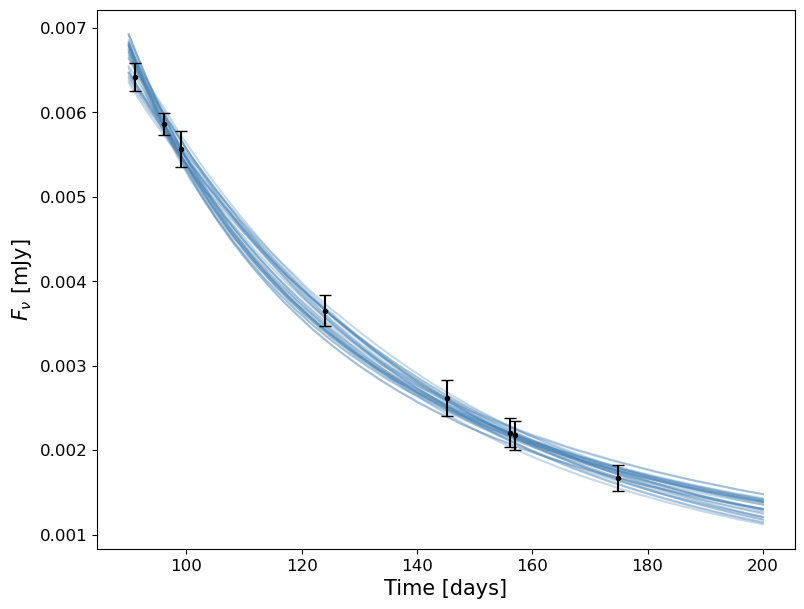

In [11]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 7))

# time used to compute fitted model
t_fit = np.geomspace(90, 200, num=100)

# plot 30 posterior samples
samples = sampler.flatchain
for s in samples[np.random.randint(len(samples), size=30)]:
    plt.plot(t_fit, model(t_fit, nu, s), color="#4682b4", alpha=0.3)

# plot the data
plt.errorbar(t, y, yerr=yerr, fmt=".k", capsize=4)
 
plt.xlabel('Time [days]', fontsize=15)
plt.ylabel(r'$F_\nu$ [mJy]', fontsize=15)

plt.show()

The best parameters are: E0 = 2.0035248933487315e+53 erg, thetaObs = 0.33509878946783245 rad, thetaWing = 0.2217189379974242 rad, n0 = 0.0788625663019812, z = 0.09575455713419571
The true parameters are: E0 = 5.508321967184549e+54 erg, thetaObs = 0.3014625731138662 rad, thetaWing = 0.22502818982075432 rad, n0 = 1.1639692277296372, z = 0.0894859334497081


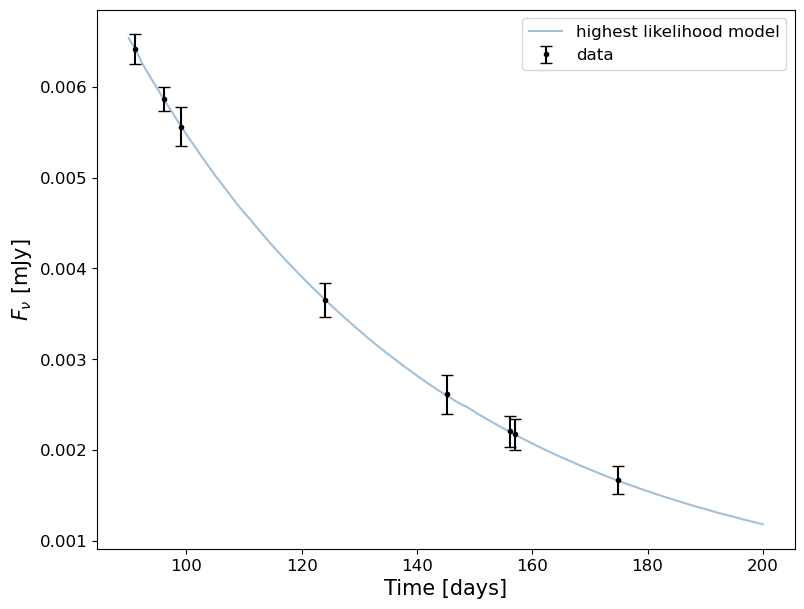

In [12]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 7))

# parameters of the max ln likelihood
best_params = samples[np.argmax(sampler.flatlnprobability)]
best_fit_model = model(t_fit, nu, best_params)

print(f"The best parameters are: E0 = {10**best_params[0]} erg, thetaObs = {best_params[1]} rad, thetaWing = {best_params[2]} rad, n0 = {10**best_params[3]}, z = {best_params[4]}")
print(f"The true parameters are: E0 = {studied_lc['config']['E0']} erg, thetaObs = {studied_lc['config']['thetaObs']} rad, thetaWing = {studied_lc['config']['thetaWing']} rad, n0 = {studied_lc['config']['n0']}, z = {studied_lc['config']['z']}")

plt.plot(t_fit, best_fit_model, color="#4682b4", alpha=0.5, label='highest likelihood model')
plt.errorbar(t, y, yerr=yerr, fmt=".k", capsize=4, label='data')

plt.xlabel('Time [days]', fontsize=15)
plt.ylabel(r'$F_\nu$ [mJy]', fontsize=15)

plt.legend()

plt.show()

In [13]:
names = [r'$logs_{10}(E_0)$', r'$\theta_{obs}$', r'$\theta_w$', r'$log_{10}(n_0)$', '$z$']
settings={'mult_bias_correction_order':0, 'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

samples_one_band = MCSamples(samples=samples, names=names, settings=settings)

Removed no burn in


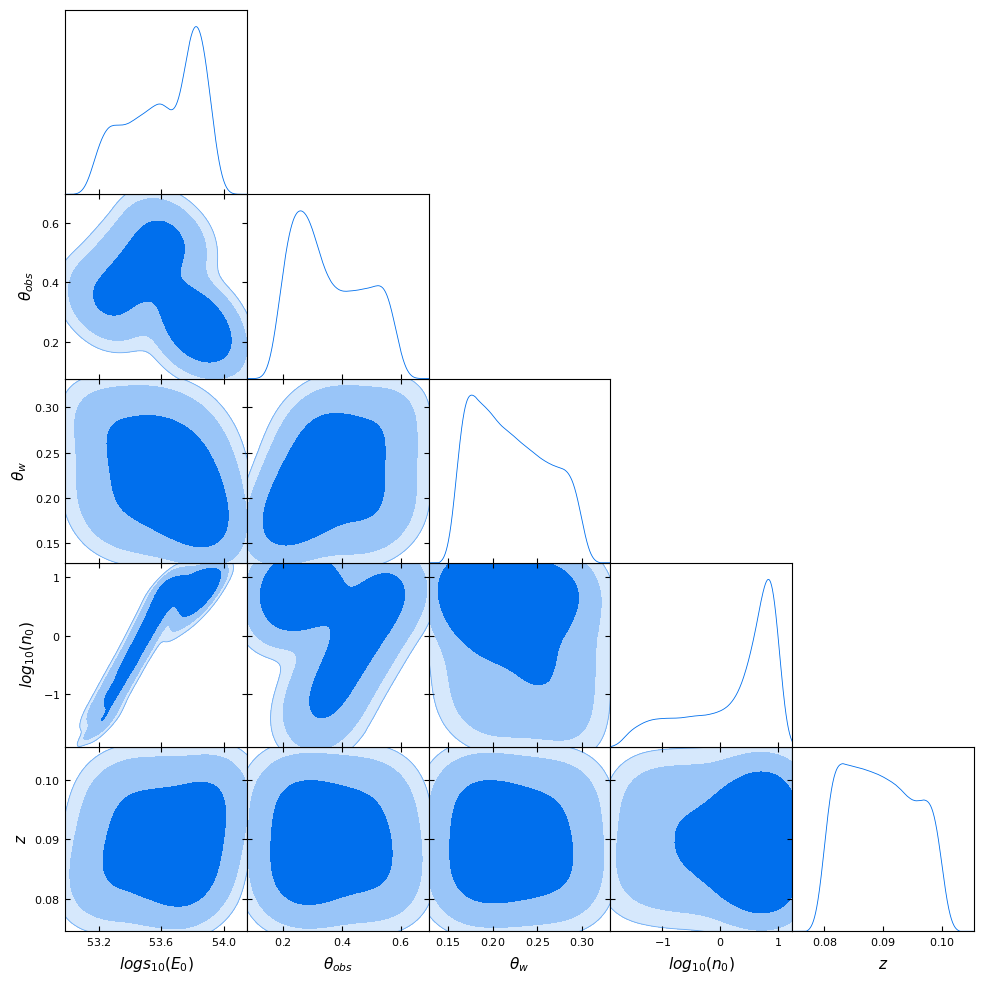

In [14]:
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 3
g.triangle_plot(samples_one_band, filled=True)

# Fitting on all bands

In [15]:
# mean frequency in Hz of each band [u, g, r, i, z, y]

all_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 298760145396604.1]
a_lambda = np.array([a_lambda_u, a_lambda_g, a_lambda_r, a_lambda_i, a_lambda_z, a_lambda_y])


# data calculated in flux and corrected from galactic extinction

t = all_times
y = pow(10, (26 - ((np.array(all_mags) - a_lambda) + 48.6) / 2.5))
yerr = pow(10, (26 - ((np.array(all_mags) - a_lambda) - np.array(all_mags_err) + 48.6) / 2.5)) - y

/tmp/ipykernel_515972/3161959696.py:10: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  y = pow(10, (26 - ((np.array(all_mags) - a_lambda) + 48.6) / 2.5))
/tmp/ipykernel_515972/3161959696.py:11: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  yerr = pow(10, (26 - ((np.array(all_mags) - a_lambda) - np.array(all_mags_err) + 48.6) / 2.5)) - y


In [16]:
def model(t, nu, params):
    
    Z = {'jetType': -1,
         'specType': 0,
         'b': 4,
         'thetaCore': 0.15,
         'p': 2.2,
         'epsilon_e': 0.1,
         'epsilon_B': 0.01,
         'xi_N': 1.0}

    E, thetaObs, thetaWing, n, z = params

    if thetaObs < thetaWing or np.pi/2 < thetaObs or z < 0.:
        thetaObs = 0.01
        z = 0.09
        
    return grb.fluxDensity(t*grb.day2sec, nu, E0=10**E, thetaObs=thetaObs, thetaWing=thetaWing, n0=10**n, z=z,
                           d_L=cosmo.luminosity_distance(z).value * 3.08e24, **Z)


def lnlike(p, t, y, yerr, nu):
    """ Compute ln of likelihood
    """
    
    return -0.5 * np.sum(((y - model(t, nu, p)) / yerr) ** 2)


def lnprior(p):
    """ Compute ln of parameters priors
    """
    
    E, thetaObs, thetaWing, n, z = p

    # uniform priors
    if (51. < E < 55. and 0.16 < thetaWing < 0.3 and thetaWing < thetaObs < np.pi/4 
        and np.log10(0.01) < n < np.log10(10.) and 0.08 < z < 0.1):
        return(0.0)

    return(-np.inf)


def lnpost(p, t, y, yerr, nu):
    """ Compute ln of parameters posteriors
    """
    
    lp = lnprior(p)
    all_lnlike = []
    
    # compute ln likelihood for each data set with at least 2 points
    for i in range(6):
        if len(y[i]) > 1:
            all_lnlike.append(lnlike(p, t[i], y[i], yerr[i], nu[i]))

    # sum of all ln likelihoods tp use all datasets in the fit
    return lp + sum(all_lnlike) if np.isfinite(lp) else -np.inf

In [17]:
# data gathered in a tuple
data = (t, y, yerr, all_nu)

nwalkers = 30

initial = np.array([54., 0.3, 0.2, 0., 0.09])
ndim = len(initial)

# initial position vector
p0 = [np.array(initial) + 1e-2 * np.random.randn(ndim)
      for i in range(nwalkers)]
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnpost, args=data)

print("Running burn-in...")
p0, _, _ = sampler.run_mcmc(p0, 500, progress=True)
sampler.reset()

print("Running production...")
sampler.run_mcmc(p0, 7500, progress=True)

print("Done!")

Running burn-in...


  0%|                                                                                                                                                                                                                                                                                                 | 0/500 [00:00<?, ?it/s]/home/masson/anaconda3/envs/orphans/lib/python3.9/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [01:22<00:00,  6.04it/s]


Running production...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7500/7500 [21:01<00:00,  5.94it/s]

Done!


/tmp/ipykernel_515972/4059223363.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string ".k" (-> color='k'). The keyword argument will take precedence.
  plt.errorbar(t[i], y[i], yerr=yerr[i], fmt=".k", capsize=4, color=colors[i])


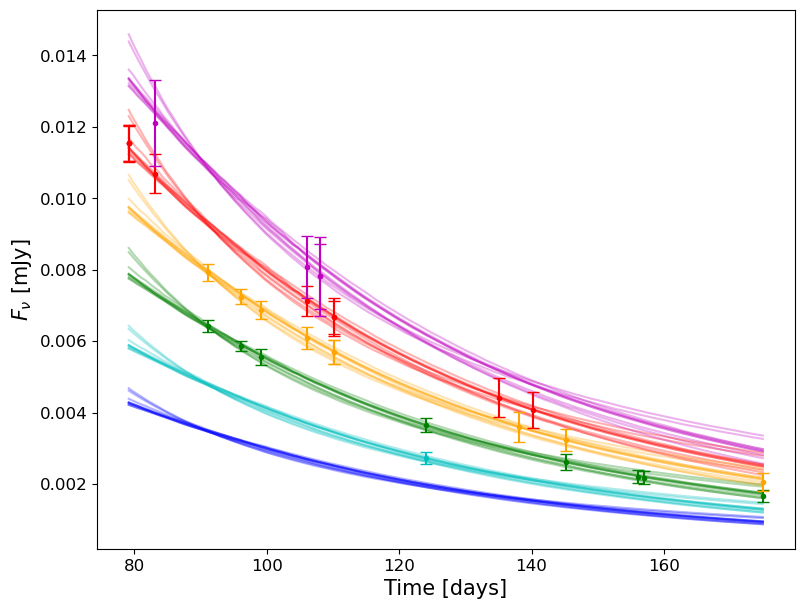

In [18]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 7))

# times of the first and last detections
t_min = min(np.min(all_times[i]) for i in range(6) if len(all_times[i]) > 0)
t_max = max(np.max(all_times[i]) for i in range(6) if len(all_times[i]) > 0)

# time used to compute fitted model
t_fit = np.geomspace(t_min, t_max, num=100)

# Plot the 10 same posterior samples for each band
samples = sampler.flatchain
for s in samples[np.random.randint(len(samples), size=10)]:
    for i in range(6):
        plt.plot(t_fit, model(t_fit, all_nu[i], s), color=colors[i], alpha=0.3)

# plot the data
for i in range(6):
    plt.errorbar(t[i], y[i], yerr=yerr[i], fmt=".k", capsize=4, color=colors[i])
    
plt.xlabel('Time [days]', fontsize=15)
plt.ylabel(r'$F_\nu$ [mJy]', fontsize=15)

plt.show()

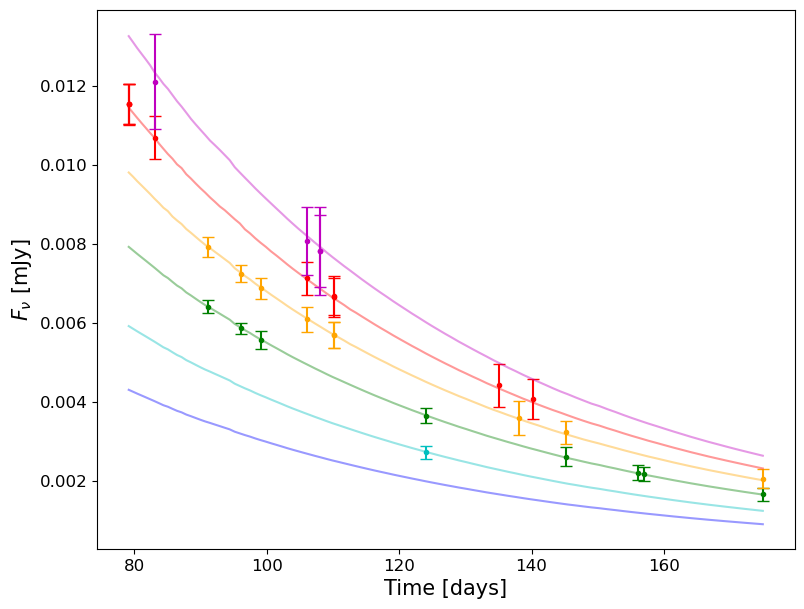

In [19]:
plt.rcParams.update({'font.size': 12})
plt.figure(figsize=(9, 7))

# parameters of the max ln likelihood
best_params = samples[np.argmax(sampler.flatlnprobability)]

for i in range(6):
    
    best_fit_model = model(t_fit, nu, best_params)
    
    plt.plot(t_fit, model(t_fit, all_nu[i], best_params), color=colors[i], alpha=0.4)
    plt.errorbar(t[i], y[i], yerr=yerr[i], capsize=4, color=colors[i], marker='o', markersize=3, linestyle='')

    
plt.xlabel('Time [days]', fontsize=15)
plt.ylabel(r'$F_\nu$ [mJy]', fontsize=15)

plt.show()

In [20]:
names = [r'$logs_{10}(E_0)$', r'$\theta_{obs}$', r'$\theta_w$', r'$log_{10}(n_0)$', '$z$']
settings={'mult_bias_correction_order':0, 'smooth_scale_2D':4, 'smooth_scale_1D':4, 'boundary_correction_order':0}

samples_all_bands = MCSamples(samples=samples, names=names, settings=settings)

Removed no burn in


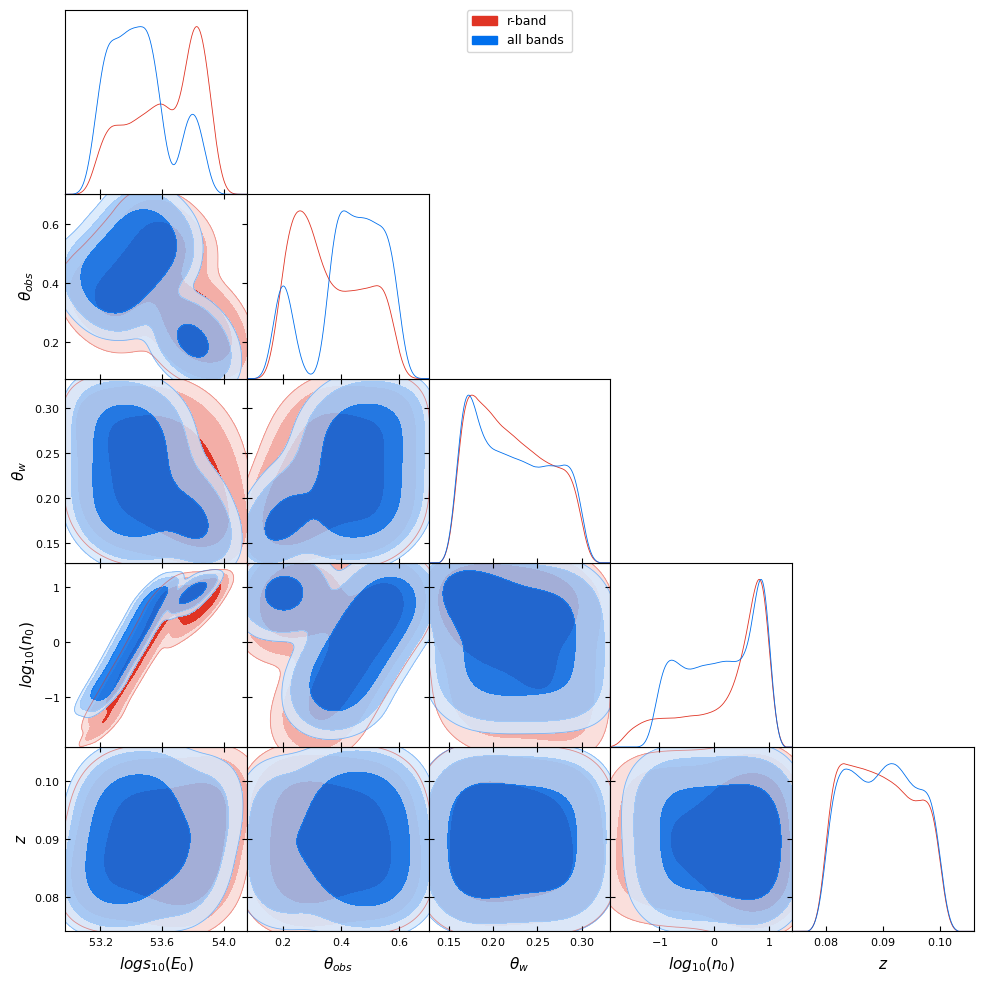

In [21]:
g = plots.get_subplot_plotter()
g.settings.num_plot_contours = 3
g.triangle_plot([samples_one_band, samples_all_bands], filled=True, legend_labels=['r-band', 'all bands '])

# Parameters values and shape of the light curve

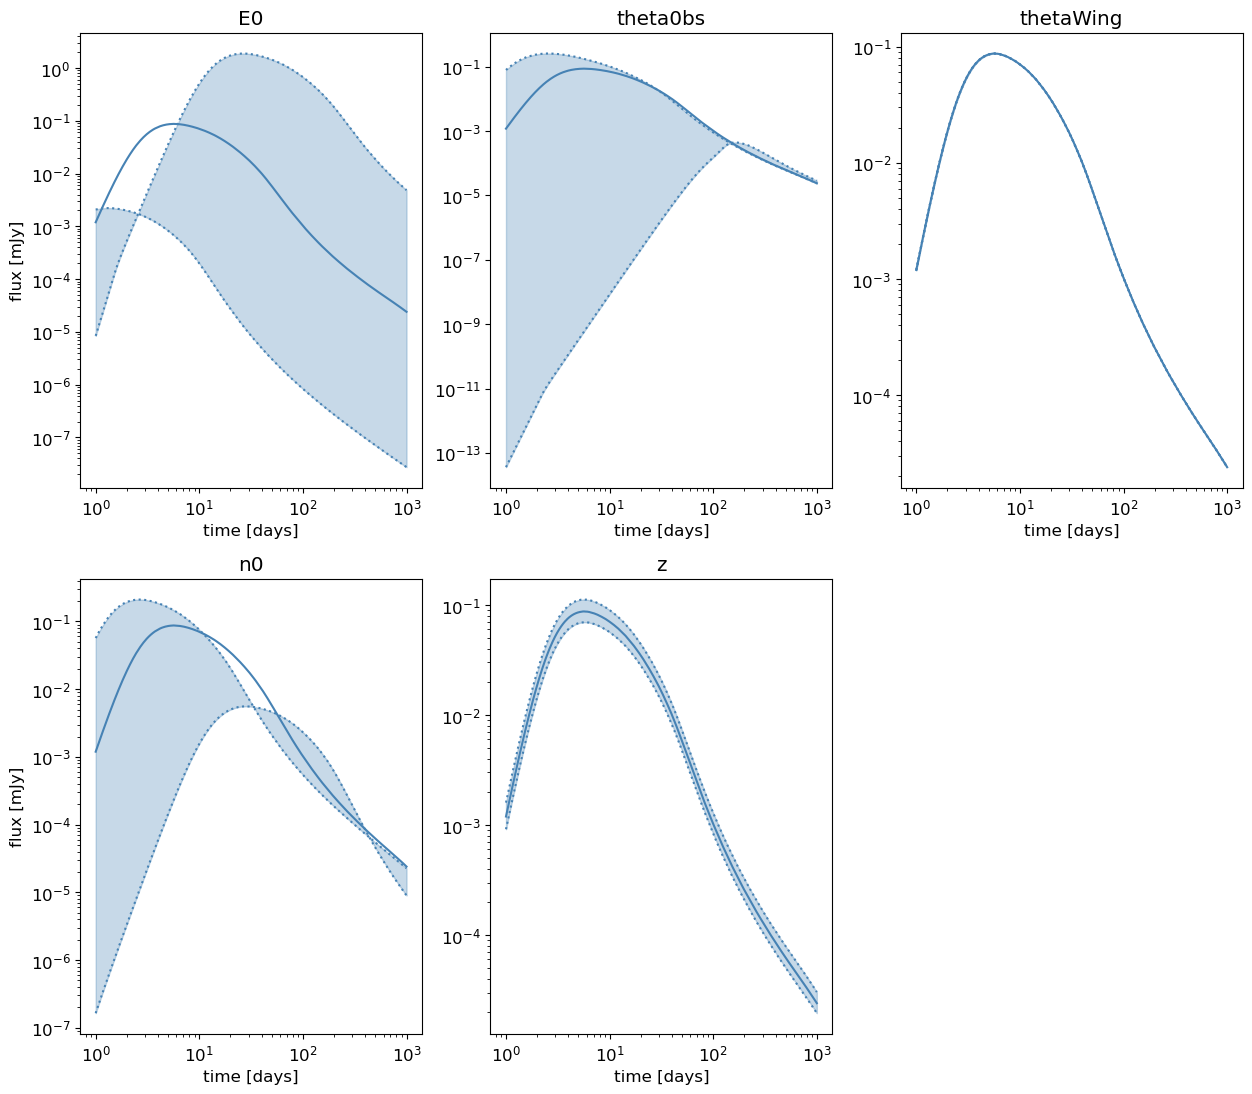

In [22]:
titles = ['E0', 'theta0bs', 'thetaWing', 'n0', 'z']

# [log10(E0), thetaObs, thetaWing, log10(n0), z] paramaters studied over the range of their value
mean_params = (53., 0.3, 0.25, 0., 0.09)
max_params = np.array([55., np.pi/4, 0.3, 1., 0.08])
min_params = np.array([51., 0.26, 0.16, -2, 0.1])

time = np.geomspace(1., 1000, 300)
nu = all_nu[2]   # r-band

# "mean" light curve for comparison
mean_model = model(time, nu, mean_params)


fig, axes = plt.subplots(figsize=(15,13), nrows=2, ncols=3)

# for each parameters, the light curves corresponding to its "max" value and its "min" value are calculated 
# and plotted to see if this parameters has a lot of impact in the shape of the light curve
for i in range(len(mean_params)):
    
    ax = plt.subplot(2,3,i+1)

    params = list(mean_params)
    
    params[i] = max_params[i]
    max_model = model(time, nu, params)
    
    params[i] = min_params[i]
    min_model = model(time, nu, params)
    
    plt.plot(time, mean_model, color="#4682b4")
    plt.plot(time, max_model, linestyle=':', color="#4682b4")
    plt.plot(time, min_model, linestyle=':', color="#4682b4")
    plt.fill_between(time, min_model, max_model, color="#4682b4", alpha = 0.3)
    
    plt.title(titles[i])
    plt.xlabel('time [days]')
    plt.xscale('log')
    plt.yscale('log')
    
axes[1][2].set_visible(False)
axes[0][0].set_ylabel('flux [mJy]')
axes[1][0].set_ylabel('flux [mJy]')
plt.show()